In [23]:
import pandas as pd

df = pd.read_csv('data/cumulative.csv')

# Only needed columns taken
# kepoi_name: The ID of the star system
# koi_disposition: Whether it's a CONFIRMED planet or a FALSE POSITIVE
# koi_period: How many days it takes the planet to orbit
# koi_prad: The estimated radius of the planet
essential_columns = ['kepoi_name', 'koi_disposition', 'koi_period', 'koi_prad']

# 10 rows taken
df[essential_columns].head(10)

,kepoi_name,koi_disposition,koi_period,koi_prad
0,K00752.01,CONFIRMED,9.488036,2.26
1,K00752.02,CONFIRMED,54.418383,2.83
2,K00753.01,FALSE POSITIVE,19.899140,14.60
3,K00754.01,FALSE POSITIVE,1.736952,33.46
4,K00755.01,CONFIRMED,2.525592,2.75
5,K00756.01,CONFIRMED,11.094321,3.90
6,K00756.02,CONFIRMED,4.134435,2.77
7,K00756.03,CONFIRMED,2.566589,1.59
8,K00114.01,FALSE POSITIVE,7.361790,39.21
9,K00757.01,CONFIRMED,16.068647,5.76


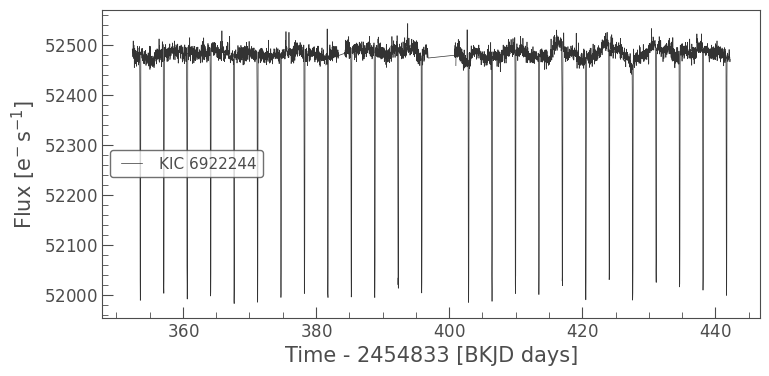

In [24]:
import lightkurve as lk
import matplotlib.pyplot as plt

# cadence='long' for narrowing the search to exactly 1 file
search_result = lk.search_lightcurve('Kepler-8', author='Kepler', quarter=4, cadence='long')

lc = search_result.download()
lc.plot()

plt.show()

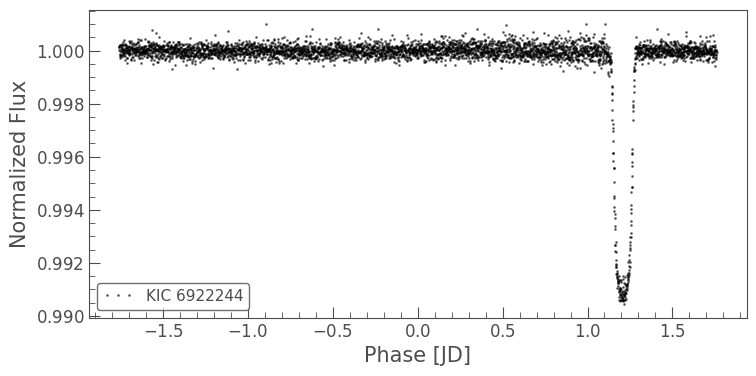

In [25]:
%matplotlib inline 
import matplotlib.pyplot as plt

# clean, flatten, and fold the data
clean_lc = lc.remove_nans()
flat_lc = clean_lc.flatten(window_length=401)
folded_lc = flat_lc.fold(period=3.5225)

folded_lc.plot(marker='.', linestyle='none', color='black', alpha=0.5)

#plot 
plt.show()

In [26]:
import numpy as np

# clean the Kaggle dataset for Machine Learning
#  only want rows that are confirmed or false positives
ml_df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
ml_df = ml_df.dropna(subset=['koi_period', 'koi_prad'])

# convert the text labels into numbers (1 for confirmed, 0 for false positive)
y = np.where(ml_df['koi_disposition'] == 'CONFIRMED', 1, 0)

# extract and normalize the features
# ai models need small, standardized numbers to learn efficiently
# applying a log transform because planetary sizes vary massively
X1 = np.log(ml_df['koi_period'].values)
X2 = np.log(ml_df['koi_prad'].values)

# Standardize the data-Z score normalization
X1 = (X1 - X1.mean()) / X1.std()
X2 = (X2 - X2.mean()) / X2.std()

# Combine 
X = np.c_[X1, X2]
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

#  start with weights and bias to zero
weights = np.zeros(X.shape[1])
bias = 0.0
learning_rate = 0.1
epochs = 1000 # number of times ai will review to learn

print("Starting training...")

# gradient descent loop 
for i in range(epochs):
    
    linear_model = np.dot(X, weights) + bias
    predictions = sigmoid(linear_model)
    
    errors = predictions - y
    
    # adjust the weights for minimizing error
    weights -= learning_rate * (1/len(y)) * np.dot(X.T, errors)
    bias -= learning_rate * (1/len(y)) * np.sum(errors)

print("Training Complete! The AI has learned the pattern.")
print(f"Final Learned Weights: {weights}")

Starting training...
Training Complete! The AI has learned the pattern.
Final Learned Weights: [ 0.20389865 -1.08578315]


Model Accuracy: 57.77%


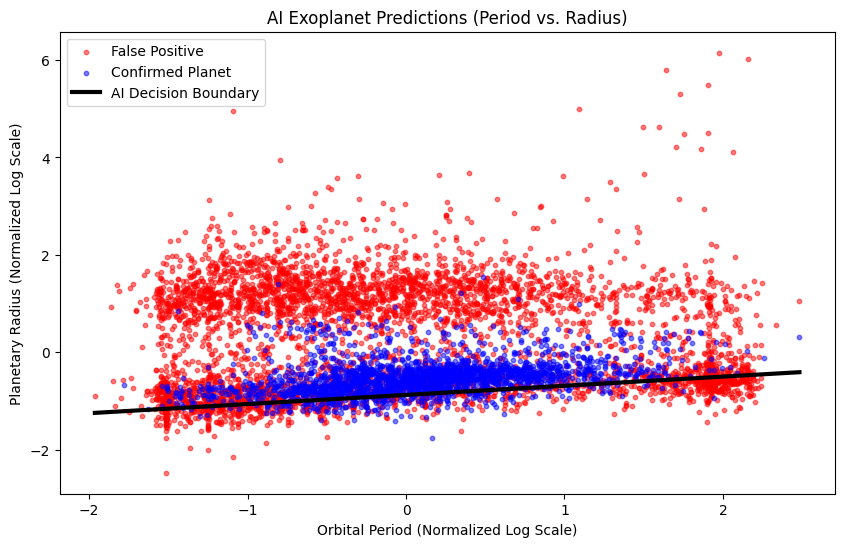

In [27]:
# calculate final predictions of ai
# probability is >= 50% (0.5) then we predict 1 (confirmed planet)
probabilities = sigmoid(np.dot(X, weights) + bias)
final_predictions = np.where(probabilities >= 0.5, 1, 0)

# calculate the accuracy score
accuracy = np.mean(final_predictions == y) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

# visualize decision boundary
plt.figure(figsize=(10, 6))

# plot the false positives(red dots) and confirmed planets (blue ones)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='False Positive', alpha=0.5, s=10)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Confirmed Planet', alpha=0.5, s=10)


# this is what is happening w1*x + w2*y + b = 0  =>  y = -(w1*x + b) / w2
x_values = np.array([X[:, 0].min(), X[:, 0].max()])
y_values = -(weights[0] * x_values + bias) / weights[1]

plt.plot(x_values, y_values, color='black', linewidth=3, label='AI Decision Boundary')

# plotting the whole thing
plt.title('AI Exoplanet Predictions (Period vs. Radius)')
plt.xlabel('Orbital Period (Normalized Log Scale)')
plt.ylabel('Planetary Radius (Normalized Log Scale)')
plt.legend()
plt.show()